ℹ️ No data to plot for flow_transport → Node: DNK
ℹ️ No data to plot for flow_transport → Node: GBR
ℹ️ No data to plot for flow_transport → Node: CHE
ℹ️ No data to plot for flow_transport → Node: NLD


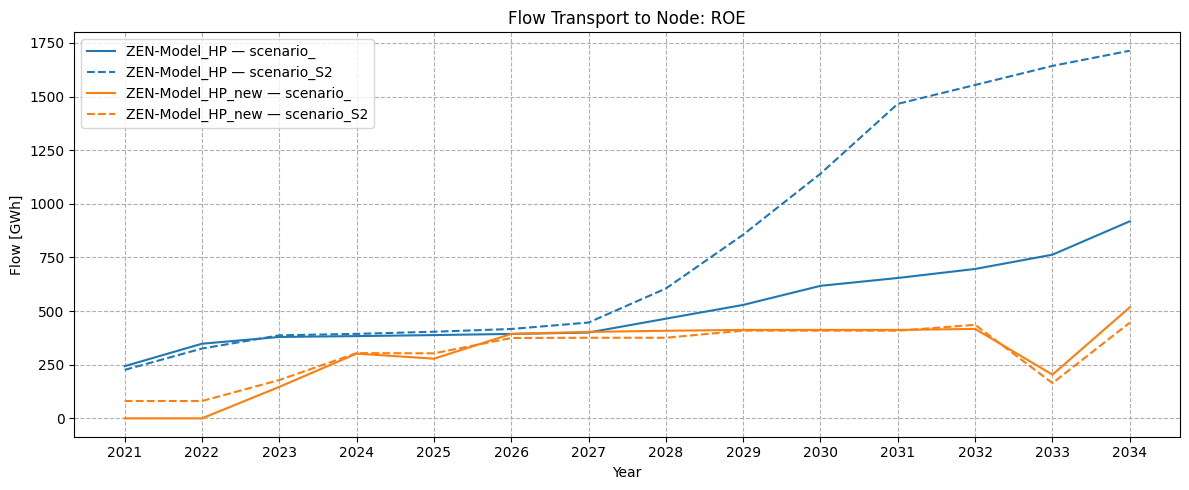

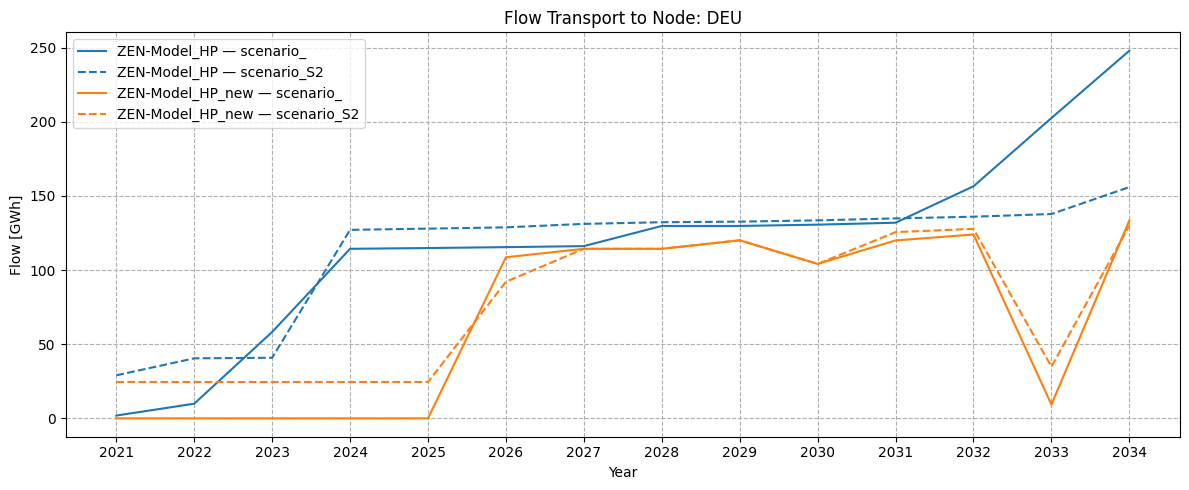

ℹ️ No data to plot for flow_transport → Node: SWE
ℹ️ No data to plot for HP_assembly → Node: DNK
ℹ️ No data to plot for HP_assembly → Node: GBR
ℹ️ No data to plot for HP_assembly → Node: CHE
ℹ️ No data to plot for HP_assembly → Node: NLD


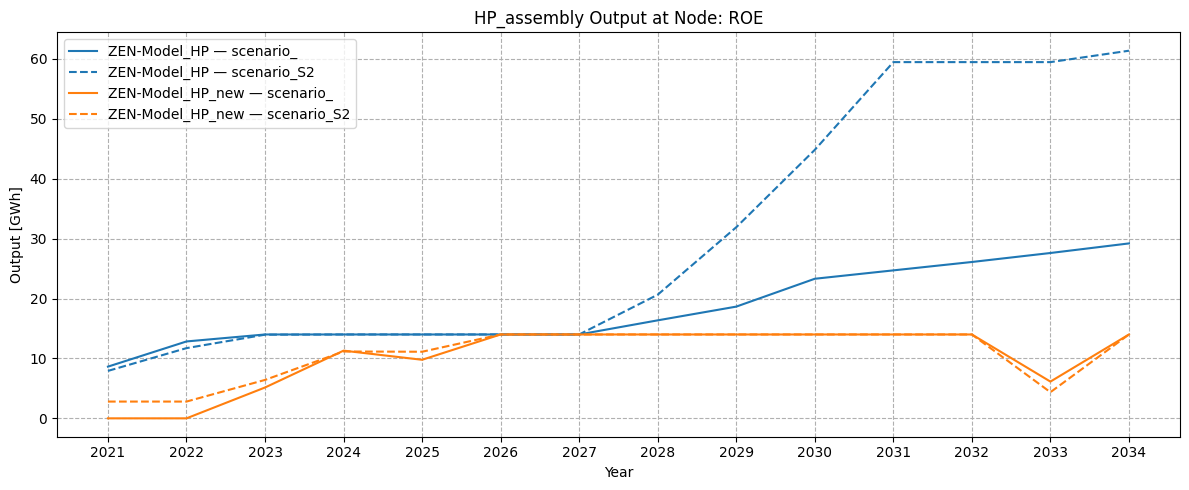

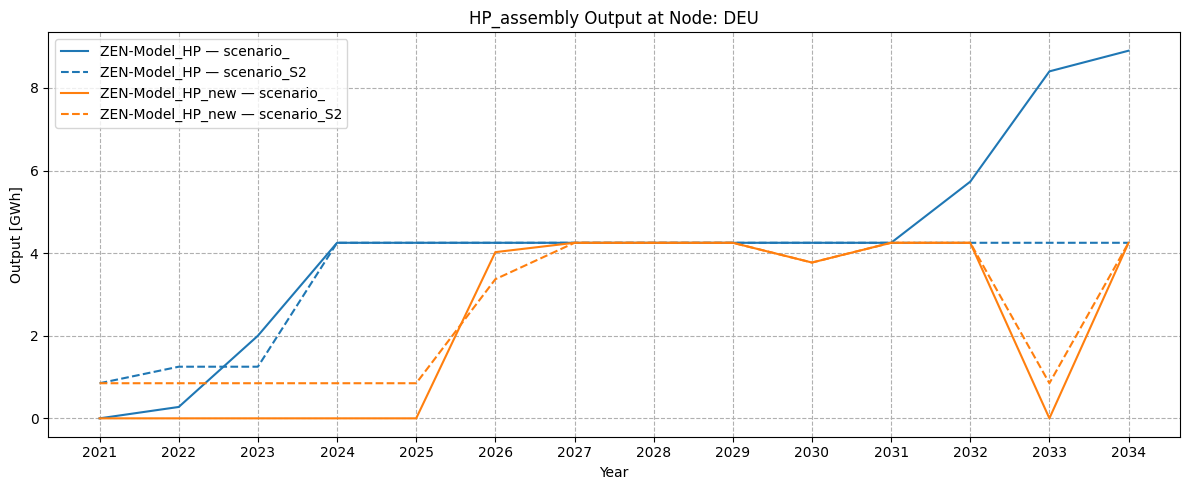

ℹ️ No data to plot for HP_assembly → Node: SWE


In [13]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from zen_garden.postprocess.results import Results

# Dataset setup
dataset_name_1 = 'ZEN-Model_HP'
dataset_name_2 = 'ZEN-Model_HP_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# Settings
variables = ['flow_transport', 'flow_conversion_output']
scenarios_to_include = ['scenario_', 'scenario_S2']
target_name = 'HP'
target_tech = 'HP_assembly'
target_nodes = {"CHE", "DEU", "DNK", "GBR", "NLD", "ROE", "SWE"}

dataset_colors = {dataset_name_1: 'tab:blue', dataset_name_2: 'tab:orange'}
scenario_styles = {"scenario_": '-', "scenario_S2": '--'}

for var in variables:
    try:
        df1_raw = r1.get_full_ts(var)
        df2_raw = r2.get_full_ts(var)

        if var == "flow_transport":
            df1_raw.index = df1_raw.index.set_names(["scenario", "technology", "edge"])
            df2_raw.index = df2_raw.index.set_names(["scenario", "technology", "edge"])
        elif var == "flow_conversion_output":
            df1_raw.index = df1_raw.index.set_names(["scenario", "technology", "carrier", "node"])
            df2_raw.index = df2_raw.index.set_names(["scenario", "technology", "carrier", "node"])

        df1 = df1_raw.reset_index()
        df2 = df2_raw.reset_index()

        if "scenario" not in df1.columns:
            df1["scenario"] = df1_raw.index.get_level_values("scenario")
            df2["scenario"] = df2_raw.index.get_level_values("scenario")

        df1 = df1[df1["scenario"].isin(scenarios_to_include)]
        df2 = df2[df2["scenario"].isin(scenarios_to_include)]

        time_cols = [col for col in df1.columns if isinstance(col, (int, float))]

        if var == "flow_transport":
            df1 = df1[df1["edge"].str.split("-").str[1].isin(target_nodes)]
            df2 = df2[df2["edge"].str.split("-").str[1].isin(target_nodes)]

            for node in target_nodes:
                plt.figure(figsize=(12, 5))
                has_data = False
                for dataset_name, df in zip([dataset_name_1, dataset_name_2], [df1, df2]):
                    df_node = df[df["edge"].str.endswith(f"-{node}")]
                    for scenario in scenarios_to_include:
                        series = df_node[df_node["scenario"] == scenario][time_cols].sum()
                        if not series.empty and series.sum() > 0:
                            has_data = True
                            plt.plot(
                                time_cols,
                                series,
                                label=f"{dataset_name} — {scenario}",
                                color=dataset_colors[dataset_name],
                                linestyle=scenario_styles[scenario]
                            )
                if has_data:
                    plt.title(f"{var.replace('_', ' ').title()} to Node: {node}")
                    plt.xlabel("Year")
                    plt.ylabel("Flow [GWh]")
                    plt.grid(True, linestyle="--")
                    plt.legend()
                    plt.tight_layout()
                    xticks_labels = [str(2021 + i) for i in range(len(time_cols))]
                    plt.xticks(ticks=time_cols, labels=xticks_labels)
                    plt.show()
                else:
                    plt.close()
                    print(f"ℹ️ No data to plot for {var} → Node: {node}")

        elif var == "flow_conversion_output":
            df1 = df1[
                (df1["technology"] == target_tech) &
                (df1["carrier"] == target_name) &
                (df1["node"].isin(target_nodes))
            ]
            df2 = df2[
                (df2["technology"] == target_tech) &
                (df2["carrier"] == target_name) &
                (df2["node"].isin(target_nodes))
            ]

            for node in target_nodes:
                plt.figure(figsize=(12, 5))
                has_data = False
                for dataset_name, df in zip([dataset_name_1, dataset_name_2], [df1, df2]):
                    df_node = df[df["node"] == node]
                    for scenario in scenarios_to_include:
                        series = df_node[df_node["scenario"] == scenario][time_cols].sum()
                        if not series.empty and series.sum() > 0:
                            has_data = True
                            plt.plot(
                                time_cols,
                                series,
                                label=f"{dataset_name} — {scenario}",
                                color=dataset_colors[dataset_name],
                                linestyle=scenario_styles[scenario]
                            )
                if has_data:
                    plt.title(f"{target_tech} Output at Node: {node}")
                    plt.xlabel("Year")
                    plt.ylabel("Output [GWh]")
                    plt.grid(True, linestyle="--")
                    plt.legend()
                    plt.tight_layout()
                    xticks_labels = [str(2021 + i) for i in range(len(time_cols))]
                    plt.xticks(ticks=time_cols, labels=xticks_labels)
                    plt.show()
                else:
                    plt.close()
                    print(f"ℹ️ No data to plot for {target_tech} → Node: {node}")

    except Exception as e:
        print(f"⚠️ Error processing '{var}': {e}")
